In [3]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Reproducibility
SEED        = 42
IMG_SIZE    = 256
BATCH_SIZE  = 32
EPOCHS      = 32
LR          = 1e-3
CLASS_NAMES = ['Benign', 'Adenocarcinoma']
AUTOTUNE    = tf.data.AUTOTUNE

np.random.seed(SEED)
tf.random.set_seed(SEED)

VALID_EXTENSIONS = ('.jpeg', '.jpg')

DATA_DIRS = {
    0: '/kaggle/input/datasets/samadolaouar/all-dataset-we-have/training_data/training_data/colon_n',
    1: '/kaggle/input/datasets/samadolaouar/all-dataset-we-have/training_data/training_data/colon_aca',
}

In [4]:
# ====================== Reinhard Normalizer ======================
class ReinhardNormalizer:
    def __init__(self):
        self.target_means = None
        self.target_stds = None

    def _lab_split(self, I):
        I_lab = cv2.cvtColor(I, cv2.COLOR_RGB2LAB).astype(np.float32)
        I1, I2, I3 = cv2.split(I_lab)
        I1 = I1 / 2.55
        I2 = I2 - 128.0
        I3 = I3 - 128.0
        return I1, I2, I3

    def _merge_back(self, I1, I2, I3):
        I1 = I1 * 2.55
        I2 = I2 + 128.0
        I3 = I3 + 128.0
        merged = np.clip(cv2.merge((I1, I2, I3)), 0, 255).astype(np.uint8)
        return cv2.cvtColor(merged, cv2.COLOR_LAB2RGB)

    def _get_mean_std(self, I):
        I1, I2, I3 = self._lab_split(I)
        m1, s1 = cv2.meanStdDev(I1)
        m2, s2 = cv2.meanStdDev(I2)
        m3, s3 = cv2.meanStdDev(I3)
        return (m1[0][0], m2[0][0], m3[0][0]), (s1[0][0], s2[0][0], s3[0][0])

    def _standardize_brightness(self, I):
        p = np.percentile(I, 95)
        return np.clip(I * 255.0 / p, 0, 255).astype(np.uint8)

    def fit(self, target):
        target = self._standardize_brightness(target)
        self.target_means, self.target_stds = self._get_mean_std(target)
        print("✅ Reinhard Normalizer fitted successfully on real reference.")

    def transform(self, I):
        I = self._standardize_brightness(I)
        I1, I2, I3 = self._lab_split(I)
        means, stds = self._get_mean_std(I)

        norm1 = ((I1 - means[0]) * (self.target_stds[0] / stds[0])) + self.target_means[0]
        norm2 = ((I2 - means[1]) * (self.target_stds[1] / stds[1])) + self.target_means[1]
        norm3 = ((I3 - means[2]) * (self.target_stds[2] / stds[2])) + self.target_means[2]

        return self._merge_back(norm1, norm2, norm3)


# ====================== Load Real Reference ======================
reference_path = "/kaggle/input/datasets/samadolaouar/all-dataset-we-have/training_data/training_data/colon_n/colonn159.jpeg"

ref_img = cv2.imread(reference_path)
ref_img = cv2.cvtColor(ref_img, cv2.COLOR_BGR2RGB)

normalizer = ReinhardNormalizer()
normalizer.fit(ref_img)

✅ Reinhard Normalizer fitted successfully on real reference.


In [5]:
def collect_paths(data_dirs: dict) -> tuple[list, list]:
    paths, labels = [], []
    for label, folder in data_dirs.items():
        for fname in sorted(os.listdir(folder)):
            if fname.lower().endswith(VALID_EXTENSIONS):
                paths.append(os.path.join(folder, fname))
                labels.append(label)
    return paths, labels

all_paths, all_labels = collect_paths(DATA_DIRS)
print(f"Total images found: {len(all_paths)}")

train_paths, tmp_paths, train_labels, tmp_labels = train_test_split(
    all_paths, all_labels, test_size=0.20, stratify=all_labels, random_state=SEED
)
val_paths, test_paths, val_labels, test_labels = train_test_split(
    tmp_paths, tmp_labels, test_size=0.50, stratify=tmp_labels, random_state=SEED
)
print(f"Train: {len(train_paths)} | Val: {len(val_paths)} | Test: {len(test_paths)}")

Total images found: 10014
Train: 8011 | Val: 1001 | Test: 1002


In [6]:
def load_and_normalize(path: str, label: int) -> tuple[np.ndarray, int]:
    img = cv2.imread(path, cv2.IMREAD_COLOR)
    if img is None:
        return np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.float32), label

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)

    # Apply Reinhard Normalization
    try:
        img = normalizer.transform(img)
    except Exception:
        pass  # fallback to original image if normalization fails

    # ResNet50 preprocessing
    img = preprocess_input(img.astype(np.float32))

    return img, label


def tf_load_and_normalize(path_tensor, label_tensor):
    img, lbl = tf.py_function(
        func=lambda p, l: load_and_normalize(
            p.numpy().decode('utf-8'),
            int(l.numpy())
        ),
        inp=[path_tensor, label_tensor],
        Tout=[tf.float32, tf.int32]
    )
    img.set_shape([IMG_SIZE, IMG_SIZE, 3])
    lbl.set_shape([])
    return img, lbl

In [7]:
def build_dataset(paths, labels, shuffle=False, repeat=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths), seed=SEED, reshuffle_each_iteration=True)
    
    ds = ds.map(tf_load_and_normalize, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE, drop_remainder=False)
    if repeat:
        ds = ds.repeat()
    ds = ds.prefetch(AUTOTUNE)
    return ds


train_ds = build_dataset(train_paths, train_labels, shuffle=True)
val_ds   = build_dataset(val_paths,   val_labels)
test_ds  = build_dataset(test_paths,  test_labels)

print(f"Steps per epoch : {len(train_paths) // BATCH_SIZE}")
print(f"Validation steps: {len(val_paths) // BATCH_SIZE}")

I0000 00:00:1778715352.456858      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Steps per epoch : 250
Validation steps: 31


In [8]:
# ── 8. Build ResNet50 Transfer-Learning Model ─────────────────────────────────
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
base_model.trainable = False

x      = base_model.output
x      = GlobalAveragePooling2D()(x)
x      = Dense(256, activation='relu')(x)
x      = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)
model.compile(
    optimizer=Adam(learning_rate=LR),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model.summary()


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 262, 262,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 128, 128,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 128, 128,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 128, 128,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 130, 130,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 64, 64,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 64, 64,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 64, 64,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 64, 64,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 64, 64,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 64, 64,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 64, 64,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 64, 64,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 64, 64,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_3_c

 Total params: 24,112,513 (91.98 MB)

 Trainable params: 524,801 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [14]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=8,           # stop if no improvement for 8 epochs
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'best_resnet50.keras',
    monitor='val_loss',
    mode='min',
    save_best_only=True,
    verbose=1
)

callbacks = [checkpoint, early_stopping]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/32
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step - accuracy: 0.9952 - loss: 0.0296
Epoch 1: val_loss improved from inf to 0.00516, saving model to best_resnet50.keras
251/251 ━━━━━━━━━━━━━━━━━━━━ 88s 351ms/step - accuracy: 0.9952 - loss: 0.0295 - val_accuracy: 0.9980 - val_loss: 0.0052
Epoch 2/32
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step - accuracy: 0.9968 - loss: 0.0168
Epoch 2: val_loss improved from 0.00516 to 0.00378, saving model to best_resnet50.keras
251/251 ━━━━━━━━━━━━━━━━━━━━ 77s 306ms/step - accuracy: 0.9968 - loss: 0.0168 - val_accuracy: 0.9980 - val_loss: 0.0038
Epoch 3/32
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step - accuracy: 0.9983 - loss: 0.0033
Epoch 3: val_loss did not improve from 0.00378
251/251 ━━━━━━━━━━━━━━━━━━━━ 77s 308ms/step - accuracy: 0.9983 - loss: 0.0033 - val_accuracy: 0.9990 - val_loss: 0.0058
Epoch 4/32
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step - accuracy: 1.0000 - loss: 1.3941e-04
Epoch 4: val_loss did not improve from 0.00378
251/251 ━━━━━━━━━━

In [15]:

base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[checkpoint]
)


Epoch 1/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step - accuracy: 1.0000 - loss: 2.1147e-04
Epoch 1: val_loss did not improve from 0.00013
251/251 ━━━━━━━━━━━━━━━━━━━━ 102s 342ms/step - accuracy: 1.0000 - loss: 2.1268e-04 - val_accuracy: 0.9970 - val_loss: 0.0136
Epoch 2/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step - accuracy: 0.9995 - loss: 9.3662e-04
Epoch 2: val_loss did not improve from 0.00013
251/251 ━━━━━━━━━━━━━━━━━━━━ 75s 298ms/step - accuracy: 0.9995 - loss: 9.3654e-04 - val_accuracy: 0.9980 - val_loss: 0.0042
Epoch 3/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step - accuracy: 0.9996 - loss: 3.9525e-04
Epoch 3: val_loss improved from 0.00013 to 0.00005, saving model to best_resnet50.keras
251/251 ━━━━━━━━━━━━━━━━━━━━ 76s 302ms/step - accuracy: 0.9996 - loss: 3.9522e-04 - val_accuracy: 1.0000 - val_loss: 4.8069e-05
Epoch 4/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step - accuracy: 1.0000 - loss: 1.2314e-04
Epoch 4: val_loss did not improve from 0.00005
251/251 ━━━━━━━━━━━━━━━━━━

32/32 ━━━━━━━━━━━━━━━━━━━━ 15s 343ms/step
                precision    recall  f1-score   support

        Benign       1.00      1.00      1.00       500
Adenocarcinoma       1.00      1.00      1.00       502

      accuracy                           1.00      1002
     macro avg       1.00      1.00      1.00      1002
  weighted avg       1.00      1.00      1.00      1002



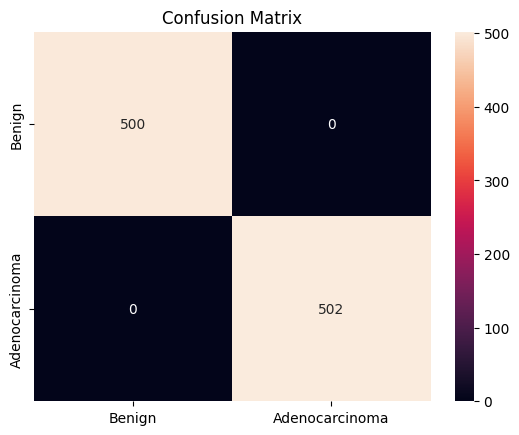

In [16]:

y_pred_probs = model.predict(test_ds)
y_pred       = (y_pred_probs > 0.5).astype(int).flatten()

# Collect ground-truth labels from the dataset (preserves order)
y_true = np.concatenate([l.numpy() for _, l in test_ds], axis=0)

print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix')
plt.show()


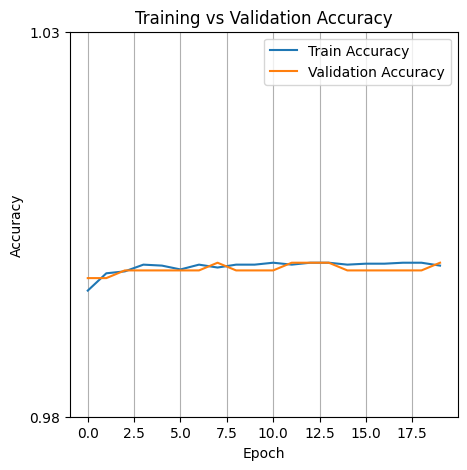

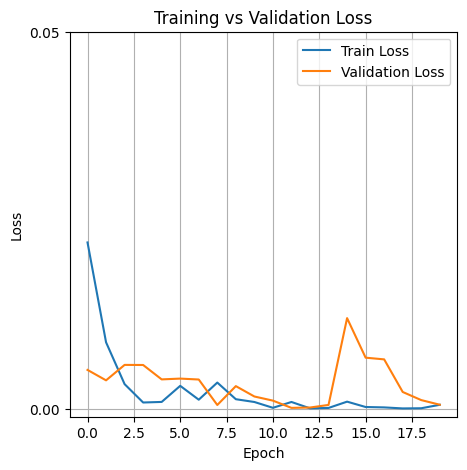

In [29]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(5,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.yticks(np.arange(0.98, 1.05, 0.05))
plt.grid(True)
plt.show()

# Loss
plt.figure(figsize=(5,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.yticks(np.arange(0, 0.1, 0.05))
plt.grid(True)
plt.show()

In [18]:
model.save('colon_cancer_final.keras')
print("Model saved to 'colon_cancer_cnn_final.keras'")


Model saved to 'colon_cancer_cnn_final.keras'


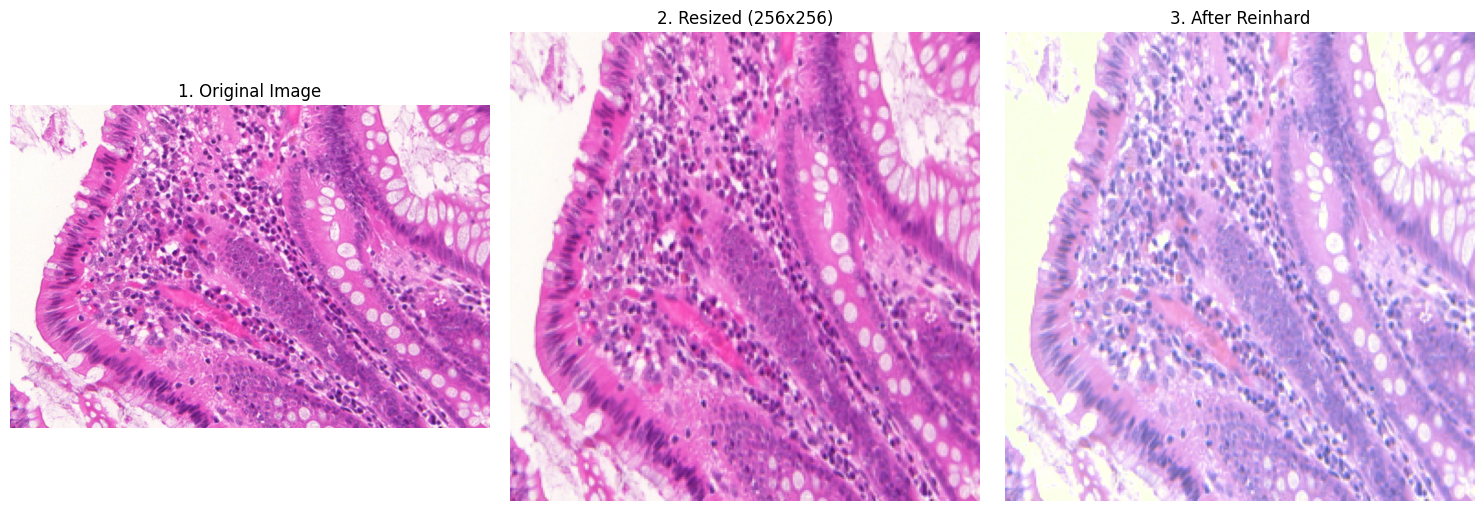

In [25]:
import cv2
import matplotlib.pyplot as plt

# ====================== Test Image ======================
test_path = "/kaggle/input/datasets/samadolaouar/normalization-test/BENIN/train_34.bmp"

# Load the image
img_bgr = cv2.imread(test_path)
img_original = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Resize (same as your training pipeline)
img_resized = cv2.resize(img_original, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)

# Apply Reinhard Normalization
img_after = normalizer.transform(img_resized.copy())

# ====================== Display Before & After ======================
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_original)
plt.title('1. Original Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(img_resized)
plt.title(f'2. Resized ({IMG_SIZE}x{IMG_SIZE})')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(img_after)
plt.title('3. After Reinhard')
plt.axis('off')

plt.tight_layout()
plt.show()